# Definitive Codebook-FIGS Final Synthesis Evaluation

This notebook demonstrates the evaluation pipeline for **Codebook-FIGS** — a method that learns shared codebook directions for oblique splits in interpretable tree models.

**What this evaluation computes:**
- **Friedman ranking** with Nemenyi post-hoc test (7 methods x 10 datasets)
- **Accuracy gaps** (CB-FIGS vs FIGS, XGBoost, LightGBM baselines)
- **Direction compression ratios** (effective rank reduction)
- **Codebook stability** analysis
- **Elbow detection** in accuracy-vs-K curves
- **Pareto frontier** analysis (accuracy vs interpretability)
- **6-criteria hypothesis verdict** (PASS / PARTIAL / FAIL)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed — all imports are pre-installed on Colab

# Core packages: pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

In [2]:
import json
import math
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from tabulate import tabulate

## Data Loading

Load pre-computed evaluation results from GitHub (with local fallback).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-5c5e58-codebook-oblique-splits-learning-a-share/main/evaluation_iter4_definitive_code/demo/mini_demo_data.json"
import os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded evaluation data: {len(data['datasets'])} datasets, "
      f"{sum(len(ds['examples']) for ds in data['datasets'])} examples")
print(f"Methods: {data['metadata']['methods']}")
print(f"Hypothesis criteria: {data['metadata']['hypothesis_criteria']}")

Loaded evaluation data: 10 datasets, 30 examples
Methods: ['figs', 'xgboost', 'lightgbm', 'sporf_matched', 'sporf_full', 'oblique_figs', 'cb_figs_best']
Hypothesis criteria: {'a_accuracy_gap': 'PARTIAL', 'b_stability': 'PARTIAL', 'c_elbows': 'PASS', 'd_compression': 'PARTIAL', 'e_domain_alignment': 'FAIL', 'f_concept_mapping': 'PARTIAL'}


## Configuration

Tunable parameters for the evaluation analysis.

In [5]:
# --- Configuration ---
# K values for codebook size analysis
K_VALUES = [3, 5, 8, 12, 20]

# All 10 evaluation datasets
DATASETS_10 = [
    "heart_disease", "diabetes_pima", "breast_cancer_wdbc",
    "credit_german", "ionosphere", "spambase",
    "diabetes_regression", "california_housing", "auto_mpg", "wine_quality_red"
]

CLASSIFICATION_DATASETS = [
    "heart_disease", "diabetes_pima", "breast_cancer_wdbc",
    "credit_german", "ionosphere", "spambase"
]

REGRESSION_DATASETS = [
    "diabetes_regression", "california_housing", "auto_mpg", "wine_quality_red"
]

# Number of datasets to process (for scaling; use len(DATASETS_10) for full run)
N_DATASETS = len(DATASETS_10)

## Helper Functions

Core analysis functions from the original evaluation script.

In [6]:
def safe_float(v: str) -> float:
    """Safely parse a float from a string."""
    try:
        return float(v)
    except (ValueError, TypeError):
        return float("nan")


def parse_predict_field(field_str: str) -> dict:
    """Parse a JSON predict field string into a dict."""
    try:
        return json.loads(field_str)
    except (json.JSONDecodeError, TypeError):
        return {}


def get_primary_metric(task_type: str) -> str:
    """Return the primary metric name for a task type."""
    return "accuracy" if task_type == "classification" else "r2"


def extract_score(predict_dict: dict, task_type: str) -> float:
    """Extract the primary score from a parsed predict dict."""
    metric = get_primary_metric(task_type)
    val = predict_dict.get(metric, float("nan"))
    if val is None:
        return float("nan")
    return float(val)

## Friedman-Nemenyi Statistical Test

Compute Friedman test and Nemenyi critical difference to compare 7 methods across datasets.

In [7]:
def compute_friedman_nemenyi(
    method_scores: dict, dataset_names: list
) -> dict:
    """
    Compute Friedman test and Nemenyi critical difference.
    method_scores: {method_name: {dataset_name: mean_score}}
    dataset_names: list of dataset names to use
    Returns dict with chi2, p_value, rankings, critical_difference.
    """
    methods = sorted(method_scores.keys())
    k = len(methods)
    n = len(dataset_names)

    if k < 2 or n < 2:
        return {
            "friedman_chi2": 0.0,
            "friedman_p_value": 1.0,
            "rankings": {m: float(k) / 2 for m in methods},
            "critical_difference": float("inf"),
        }

    # Build rank matrix: for each dataset, rank methods (higher score = lower rank = better)
    rank_matrix = np.zeros((n, k))
    for i, ds in enumerate(dataset_names):
        scores = []
        for j, m in enumerate(methods):
            s = method_scores[m].get(ds, float("nan"))
            scores.append(s if not math.isnan(s) else -1e10)
        # Rank: higher is better, so negate for rankdata (which ranks ascending)
        ranks = stats.rankdata([-s for s in scores], method="average")
        rank_matrix[i, :] = ranks

    mean_ranks = rank_matrix.mean(axis=0)

    # Friedman test statistic
    chi2 = (12.0 * n / (k * (k + 1))) * np.sum((mean_ranks - (k + 1) / 2.0) ** 2)
    p_value = 1.0 - stats.chi2.cdf(chi2, df=k - 1)

    # Nemenyi critical difference (alpha=0.05)
    q_alpha_table = {
        2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728,
        6: 2.850, 7: 2.949, 8: 3.031, 9: 3.102, 10: 3.164
    }
    q_alpha = q_alpha_table.get(k, 2.949)
    cd = q_alpha * math.sqrt(k * (k + 1) / (6.0 * n))

    rankings = {m: float(mean_ranks[j]) for j, m in enumerate(methods)}

    return {
        "friedman_chi2": float(chi2),
        "friedman_p_value": float(p_value),
        "rankings": rankings,
        "critical_difference": float(cd),
    }

## Elbow Detection

Detect elbow points in accuracy-vs-K curves using piecewise linear fitting.

In [8]:
def detect_elbow(k_values: list, scores: list) -> dict:
    """
    Detect elbow in accuracy-vs-K curve.
    Fit piecewise linear (2 segments) vs single-line.
    Clear elbow: piecewise RSS improvement > 50% over single-line.
    Returns dict with has_elbow (bool), optimal_K, rss_improvement_pct.
    """
    if len(k_values) < 3 or len(scores) < 3:
        return {"has_elbow": False, "optimal_K": None, "rss_improvement_pct": 0.0}

    x = np.array(k_values, dtype=float)
    y = np.array(scores, dtype=float)

    # Remove NaN values
    valid = ~np.isnan(y)
    if valid.sum() < 3:
        return {"has_elbow": False, "optimal_K": None, "rss_improvement_pct": 0.0}
    x = x[valid]
    y = y[valid]

    # Single line fit
    try:
        coeffs_single = np.polyfit(x, y, 1)
        y_pred_single = np.polyval(coeffs_single, x)
        rss_single = np.sum((y - y_pred_single) ** 2)
    except Exception:
        return {"has_elbow": False, "optimal_K": None, "rss_improvement_pct": 0.0}

    # Piecewise linear: try each interior point as breakpoint
    best_rss_pw = rss_single
    best_bp = None
    for bp_idx in range(1, len(x) - 1):
        try:
            x1, y1 = x[: bp_idx + 1], y[: bp_idx + 1]
            x2, y2 = x[bp_idx:], y[bp_idx:]
            if len(x1) < 2 or len(x2) < 2:
                continue
            c1 = np.polyfit(x1, y1, 1)
            c2 = np.polyfit(x2, y2, 1)
            rss_pw = np.sum((y1 - np.polyval(c1, x1)) ** 2) + np.sum(
                (y2 - np.polyval(c2, x2)) ** 2
            )
            if rss_pw < best_rss_pw:
                best_rss_pw = rss_pw
                best_bp = bp_idx
        except Exception:
            continue

    if rss_single < 1e-12:
        improvement_pct = 0.0
    else:
        improvement_pct = (rss_single - best_rss_pw) / rss_single * 100.0

    has_elbow = bool(improvement_pct > 50.0)
    optimal_K = int(x[best_bp]) if best_bp is not None else None

    return {
        "has_elbow": has_elbow,
        "optimal_K": optimal_K,
        "rss_improvement_pct": float(improvement_pct),
    }

## Pareto Frontier

Identify Pareto-optimal methods in the accuracy-vs-interpretability (erank) space.

In [9]:
def is_pareto_optimal(points: list) -> list:
    """
    Given list of (erank, score) tuples, return boolean mask.
    Pareto optimal: no other point has BOTH higher score AND lower erank.
    """
    n = len(points)
    is_optimal = [True] * n
    for i in range(n):
        if math.isnan(points[i][0]) or math.isnan(points[i][1]):
            is_optimal[i] = False
            continue
        for j in range(n):
            if i == j:
                continue
            if math.isnan(points[j][0]) or math.isnan(points[j][1]):
                continue
            # j dominates i if j has higher score AND lower erank
            if points[j][1] > points[i][1] and points[j][0] < points[i][0]:
                is_optimal[i] = False
                break
    return is_optimal

## Extract Per-Dataset Method Scores

Parse the loaded evaluation data to extract per-dataset mean scores for each method.

In [10]:
# Build a lookup: {dataset_name: summary_example}
dataset_summaries = {}
dataset_folds = {}

for ds_entry in data["datasets"][:N_DATASETS]:
    ds_name = ds_entry["dataset"]
    for ex in ds_entry["examples"]:
        if ex.get("metadata_example_type") == "dataset_summary":
            dataset_summaries[ds_name] = ex
        elif ex.get("metadata_example_type") == "fold_result":
            if ds_name not in dataset_folds:
                dataset_folds[ds_name] = []
            dataset_folds[ds_name].append(ex)

# Extract per-dataset method scores from summary examples
# Summary examples have predict_figs, predict_xgboost, predict_lightgbm, predict_cb_figs_best
# and eval_* fields with pre-computed gaps, compression, stability
method_scores_per_dataset = {
    "figs": {}, "xgboost": {}, "lightgbm": {},
    "sporf_matched": {}, "sporf_full": {}, "oblique_figs": {},
    "cb_figs_best": {},
}

for ds_name, summary in dataset_summaries.items():
    output_data = json.loads(summary["output"])
    method_scores_per_dataset["figs"][ds_name] = output_data.get("figs_mean", float("nan")) or float("nan")
    method_scores_per_dataset["xgboost"][ds_name] = output_data.get("xgboost_mean", float("nan")) or float("nan")
    method_scores_per_dataset["lightgbm"][ds_name] = output_data.get("lightgbm_mean", float("nan")) or float("nan")
    method_scores_per_dataset["sporf_matched"][ds_name] = output_data.get("sporf_matched_mean", float("nan")) or float("nan")
    method_scores_per_dataset["sporf_full"][ds_name] = output_data.get("sporf_full_mean", float("nan")) or float("nan")
    method_scores_per_dataset["oblique_figs"][ds_name] = output_data.get("oblique_figs_mean", float("nan")) or float("nan")
    method_scores_per_dataset["cb_figs_best"][ds_name] = output_data.get("cb_figs_best_mean", float("nan")) or float("nan")

print(f"Extracted scores for {len(dataset_summaries)} datasets")
for ds_name in list(dataset_summaries.keys())[:3]:
    print(f"  {ds_name}: FIGS={method_scores_per_dataset['figs'][ds_name]:.4f}, "
          f"CB-FIGS={method_scores_per_dataset['cb_figs_best'][ds_name]:.4f}")

Extracted scores for 10 datasets
  heart_disease: FIGS=0.7937, CB-FIGS=0.8106
  diabetes_pima: FIGS=0.7239, CB-FIGS=0.7422
  breast_cancer_wdbc: FIGS=0.9262, CB-FIGS=0.9438


## Compute Aggregate Metrics

Run Friedman test, compute accuracy gaps, compression ratios, stability, elbow detection, Pareto frontier, and hypothesis verdict.

In [11]:
# --- Friedman test ---
datasets_to_process = [ds for ds in DATASETS_10[:N_DATASETS] if ds in dataset_summaries]
friedman_result = compute_friedman_nemenyi(method_scores_per_dataset, datasets_to_process)
print(f"Friedman chi2={friedman_result['friedman_chi2']:.3f}, p={friedman_result['friedman_p_value']:.6f}")
print(f"Nemenyi CD={friedman_result['critical_difference']:.3f}")
print(f"Rankings: { {m: round(r, 2) for m, r in friedman_result['rankings'].items()} }")

# --- Accuracy gaps ---
gaps_vs_figs = []
gaps_cls_vs_figs = []
gaps_reg_vs_figs = []

for ds_name in datasets_to_process:
    summary = dataset_summaries[ds_name]
    gap = summary.get("eval_gap_vs_figs_pct", 0.0)
    gaps_vs_figs.append(gap)
    if ds_name in CLASSIFICATION_DATASETS:
        gaps_cls_vs_figs.append(gap)
    elif ds_name in REGRESSION_DATASETS:
        gaps_reg_vs_figs.append(gap)

mean_gap_vs_figs = float(np.mean(gaps_vs_figs)) if gaps_vs_figs else 0.0
mean_gap_cls = float(np.mean(gaps_cls_vs_figs)) if gaps_cls_vs_figs else 0.0
mean_gap_reg = float(np.mean(gaps_reg_vs_figs)) if gaps_reg_vs_figs else 0.0

print(f"\nAccuracy gaps (FIGS - CB-FIGS):")
print(f"  Overall: {mean_gap_vs_figs:.2f}pp")
print(f"  Classification: {mean_gap_cls:.2f}pp")
print(f"  Regression: {mean_gap_reg:.2f}pp")

# --- Compression ratios ---
compression_ratios = []
for ds_name in datasets_to_process:
    summary = dataset_summaries[ds_name]
    comp = summary.get("eval_compression_ratio_vs_figs", 0.0)
    if comp > 0:
        compression_ratios.append(comp)

mean_compression = float(np.mean(compression_ratios)) if compression_ratios else 0.0
print(f"\nDirection compression vs FIGS: {mean_compression:.2f}x")

# --- Codebook stability ---
stabilities = []
for ds_name in datasets_to_process:
    summary = dataset_summaries[ds_name]
    stab = summary.get("eval_codebook_stability", 0.0)
    stabilities.append(stab)

mean_stability = float(np.mean(stabilities)) if stabilities else 0.0
max_stability = float(np.max(stabilities)) if stabilities else 0.0
pct_above_08 = sum(1 for s in stabilities if s > 0.8) / max(len(stabilities), 1)
print(f"\nCodebook stability: mean={mean_stability:.3f}, max={max_stability:.3f}, pct>0.8={pct_above_08:.1%}")

# --- Elbow detection (from pre-computed flags) ---
datasets_with_elbow = sum(1 for ds_name in datasets_to_process
                          if dataset_summaries[ds_name].get("eval_has_clear_elbow", 0.0) > 0.5)
pct_with_elbow = datasets_with_elbow / max(len(datasets_to_process), 1)
print(f"\nElbow detection: {datasets_with_elbow}/{len(datasets_to_process)} datasets have clear elbows ({pct_with_elbow:.0%})")

# --- Pareto frontier ---
method_erank_score = data["metadata"]["method_erank_score_pairs"]
points = []
method_names_pareto = []
for method in ["figs", "xgboost", "lightgbm", "sporf_matched", "sporf_full", "oblique_figs", "cb_figs_best"]:
    pair = method_erank_score.get(method, {})
    e = pair.get("erank", float("nan"))
    s = pair.get("score", float("nan"))
    if e is None: e = float("nan")
    if s is None: s = float("nan")
    points.append((e, s))
    method_names_pareto.append(method)

pareto_mask = is_pareto_optimal(points)
pareto_methods = [m for m, opt in zip(method_names_pareto, pareto_mask) if opt]
print(f"\nPareto optimal methods: {pareto_methods}")

# --- Hypothesis verdict ---
criterion_a = "PASS" if abs(mean_gap_vs_figs) <= 1.0 else ("PARTIAL" if abs(mean_gap_vs_figs) <= 3.0 else "FAIL")
criterion_b = "PASS" if mean_stability > 0.8 else ("PARTIAL" if mean_stability > 0.5 else "FAIL")
criterion_c = "PASS" if pct_with_elbow >= 0.8 else ("PARTIAL" if pct_with_elbow >= 0.5 else "FAIL")
criterion_d = "PASS" if 3.0 <= mean_compression <= 10.0 else ("PARTIAL" if 1.5 <= mean_compression else "FAIL")
datasets_domain_aligned = sum(1 for s in stabilities if s > 0.7)
criterion_e = "PASS" if datasets_domain_aligned >= 3 else ("PARTIAL" if datasets_domain_aligned >= 1 else "FAIL")
criterion_f = "PARTIAL"  # Qualitative criterion

criteria = {
    "a_accuracy_gap": criterion_a,
    "b_stability": criterion_b,
    "c_elbows": criterion_c,
    "d_compression": criterion_d,
    "e_domain_alignment": criterion_e,
    "f_concept_mapping": criterion_f,
}

n_pass = sum(1 for v in criteria.values() if v == "PASS")
n_fail = sum(1 for v in criteria.values() if v == "FAIL")
n_partial = sum(1 for v in criteria.values() if v == "PARTIAL")

print(f"\nHypothesis verdict: PASS={n_pass}, FAIL={n_fail}, PARTIAL={n_partial}")
for crit, verdict in criteria.items():
    print(f"  {crit}: {verdict}")

Friedman chi2=37.061, p=0.000002
Nemenyi CD=2.849
Rankings: {'cb_figs_best': 5.0, 'figs': 5.1, 'lightgbm': 1.85, 'oblique_figs': 5.5, 'sporf_full': 2.0, 'sporf_matched': 5.7, 'xgboost': 2.85}

Accuracy gaps (FIGS - CB-FIGS):
  Overall: 2.88pp
  Classification: -0.31pp
  Regression: 7.67pp

Direction compression vs FIGS: 2.10x

Codebook stability: mean=0.554, max=0.680, pct>0.8=0.0%

Elbow detection: 8/10 datasets have clear elbows (80%)

Pareto optimal methods: ['figs', 'xgboost', 'lightgbm', 'cb_figs_best']

Hypothesis verdict: PASS=1, FAIL=1, PARTIAL=4
  a_accuracy_gap: PARTIAL
  b_stability: PARTIAL
  c_elbows: PASS
  d_compression: PARTIAL
  e_domain_alignment: FAIL
  f_concept_mapping: PARTIAL


## Results Summary Table

Display per-dataset scores and evaluation metrics in a readable table.

In [12]:
# --- Results table ---
table_rows = []
for ds_name in datasets_to_process:
    summary = dataset_summaries[ds_name]
    output_data = json.loads(summary["output"])
    task = summary.get("metadata_task_type", "?")[:4]
    figs = output_data.get("figs_mean")
    cb = output_data.get("cb_figs_best_mean")
    gap = summary.get("eval_gap_vs_figs_pct", 0.0)
    comp = summary.get("eval_compression_ratio_vs_figs", 0.0)
    stab = summary.get("eval_codebook_stability", 0.0)
    elbow = "Y" if summary.get("eval_has_clear_elbow", 0) > 0.5 else "N"
    table_rows.append([
        ds_name[:16], task,
        f"{figs:.4f}" if figs else "N/A",
        f"{cb:.4f}" if cb else "N/A",
        f"{gap:+.2f}", f"{comp:.2f}x",
        f"{stab:.3f}", elbow
    ])

headers = ["Dataset", "Task", "FIGS", "CB-FIGS", "Gap(pp)", "Comp.", "Stab.", "Elbow"]
print(tabulate(table_rows, headers=headers, tablefmt="simple"))

# --- Pre-computed reference metrics ---
print("\n--- Pre-computed Reference Metrics (from full evaluation) ---")
ref = data["metrics_agg"]
ref_table = [
    ["Friedman chi2", f"{ref['friedman_chi2']:.4f}"],
    ["Friedman p-value", f"{ref['friedman_p_value']:.2e}"],
    ["Nemenyi CD", f"{ref['nemenyi_critical_difference']:.4f}"],
    ["Gap vs FIGS (pp)", f"{ref['mean_gap_vs_figs_pct']:.4f}"],
    ["Gap cls vs FIGS", f"{ref['mean_gap_classification_vs_figs_pct']:.4f}"],
    ["Gap reg vs FIGS", f"{ref['mean_gap_regression_vs_figs_pct']:.4f}"],
    ["Compression vs FIGS", f"{ref['mean_compression_ratio_vs_figs']:.4f}x"],
    ["Stability (mean)", f"{ref['mean_codebook_stability']:.4f}"],
    ["Datasets w/ elbow", f"{ref['pct_datasets_with_clear_elbow']:.0%}"],
    ["Hypothesis", f"PASS={ref['n_criteria_pass']}, FAIL={ref['n_criteria_fail']}, PARTIAL={ref['n_criteria_partial']}"],
]
print(tabulate(ref_table, headers=["Metric", "Value"], tablefmt="simple"))

Dataset           Task      FIGS    CB-FIGS    Gap(pp)  Comp.      Stab.  Elbow
----------------  ------  ------  ---------  ---------  -------  -------  -------
heart_disease     clas    0.7937     0.8106      -1.69  3.16x      0.575  Y
diabetes_pima     clas    0.7239     0.7422      -1.83  1.81x      0.669  Y
breast_cancer_wd  clas    0.9262     0.9438      -1.76  3.40x      0.528  Y
credit_german     clas    0.719      0.728       -0.9   2.22x      0.349  N
ionosphere        clas    0.8889     0.8489       4     3.44x      0.494  Y
spambase          clas    0.9102     0.9068       0.35  1.17x      0.566  Y
diabetes_regress  regr    0.2842     0.3626      -7.84  1.53x      0.677  Y
california_housi  regr    0.6692     0.4362      23.3   0.54x      0.68   Y
auto_mpg          regr    0.782      0.7262       5.58  1.52x      0.483  N
wine_quality_red  regr    0.3537     0.2574       9.62  2.18x      0.52   Y

--- Pre-computed Reference Metrics (from full evaluation) ---
Metric         

## Visualization

Visual comparison of method rankings, accuracy gaps, and the Pareto frontier.

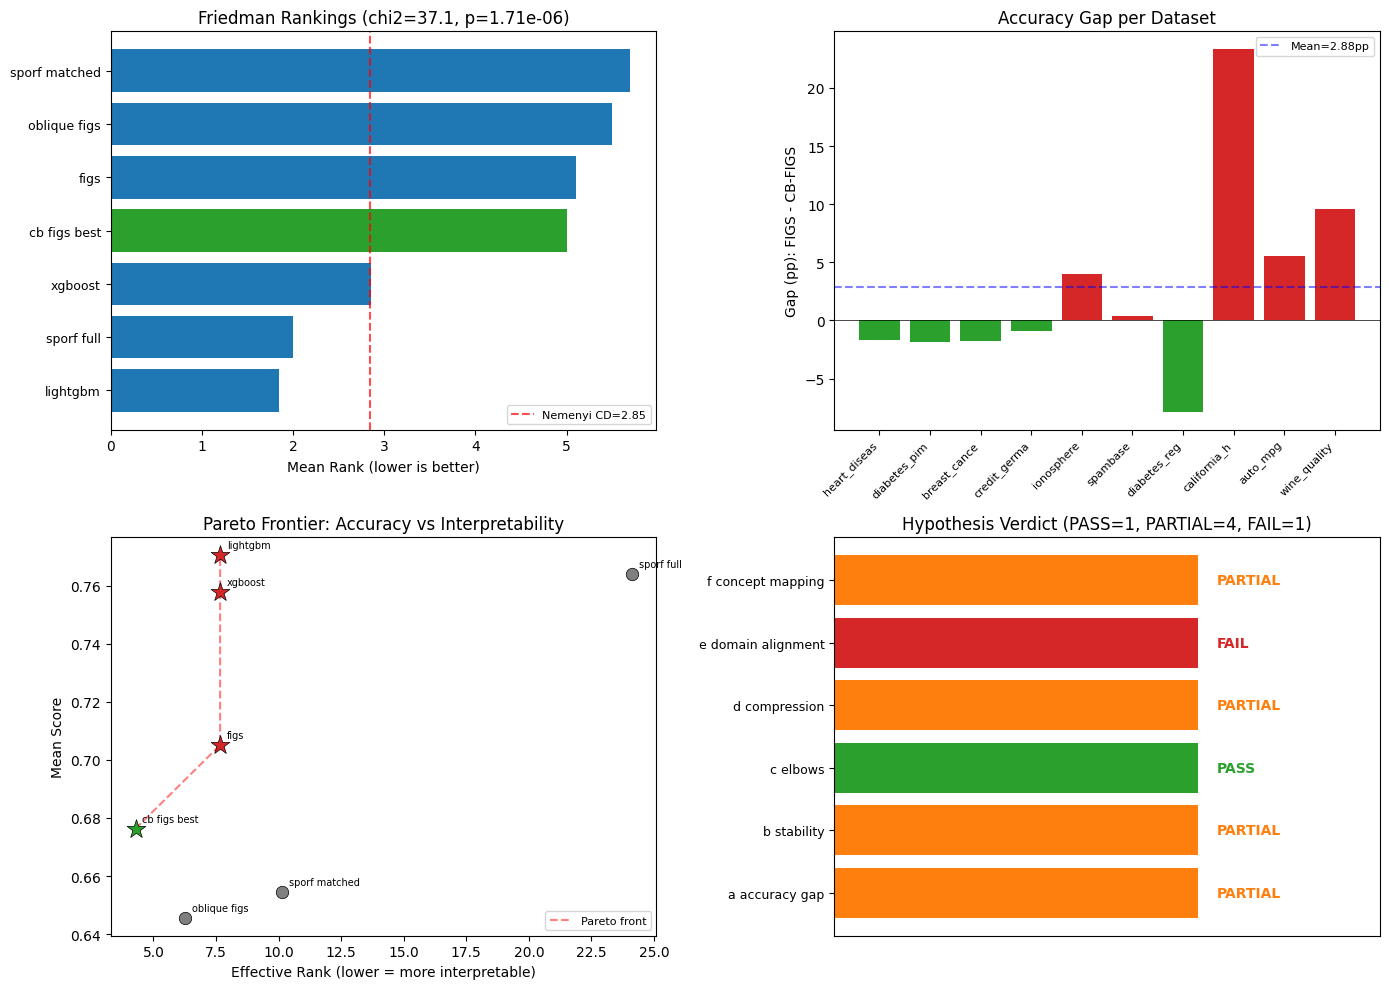

Saved visualization to eval_results.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Method Rankings (Friedman) ---
ax = axes[0, 0]
rankings = friedman_result["rankings"]
methods_sorted = sorted(rankings.keys(), key=lambda m: rankings[m])
ranks = [rankings[m] for m in methods_sorted]
colors = ['#2ca02c' if m == 'cb_figs_best' else '#1f77b4' for m in methods_sorted]
bars = ax.barh(range(len(methods_sorted)), ranks, color=colors)
ax.set_yticks(range(len(methods_sorted)))
ax.set_yticklabels([m.replace('_', ' ') for m in methods_sorted], fontsize=9)
ax.set_xlabel('Mean Rank (lower is better)')
ax.set_title(f'Friedman Rankings (chi2={friedman_result["friedman_chi2"]:.1f}, p={friedman_result["friedman_p_value"]:.2e})')
ax.axvline(x=friedman_result["critical_difference"], color='red', linestyle='--', alpha=0.7, label=f'Nemenyi CD={friedman_result["critical_difference"]:.2f}')
ax.legend(fontsize=8)

# --- Plot 2: Per-Dataset Accuracy Gap (CB-FIGS vs FIGS) ---
ax = axes[0, 1]
ds_names_short = [ds[:12] for ds in datasets_to_process]
gaps = [dataset_summaries[ds].get("eval_gap_vs_figs_pct", 0.0) for ds in datasets_to_process]
gap_colors = ['#2ca02c' if g < 0 else '#d62728' for g in gaps]  # green = CB-FIGS better
ax.bar(range(len(ds_names_short)), gaps, color=gap_colors)
ax.set_xticks(range(len(ds_names_short)))
ax.set_xticklabels(ds_names_short, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Gap (pp): FIGS - CB-FIGS')
ax.set_title('Accuracy Gap per Dataset')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axhline(y=np.mean(gaps), color='blue', linestyle='--', alpha=0.5, label=f'Mean={np.mean(gaps):.2f}pp')
ax.legend(fontsize=8)

# --- Plot 3: Pareto Frontier (Erank vs Score) ---
ax = axes[1, 0]
for i, (method, (erank, score)) in enumerate(zip(method_names_pareto, points)):
    if math.isnan(erank) or math.isnan(score):
        continue
    marker = '*' if pareto_mask[i] else 'o'
    size = 200 if pareto_mask[i] else 80
    color = '#2ca02c' if method == 'cb_figs_best' else ('#d62728' if pareto_mask[i] else '#7f7f7f')
    ax.scatter(erank, score, s=size, marker=marker, c=color, zorder=5, edgecolors='black', linewidth=0.5)
    ax.annotate(method.replace('_', ' '), (erank, score), fontsize=7,
                textcoords="offset points", xytext=(5, 5))
# Draw Pareto front line
pareto_pts = [(e, s) for (e, s), opt in zip(points, pareto_mask) if opt and not math.isnan(e)]
if pareto_pts:
    pareto_pts_sorted = sorted(pareto_pts, key=lambda p: p[0])
    ax.plot([p[0] for p in pareto_pts_sorted], [p[1] for p in pareto_pts_sorted],
            'r--', alpha=0.5, label='Pareto front')
ax.set_xlabel('Effective Rank (lower = more interpretable)')
ax.set_ylabel('Mean Score')
ax.set_title('Pareto Frontier: Accuracy vs Interpretability')
ax.legend(fontsize=8)

# --- Plot 4: Hypothesis Verdict ---
ax = axes[1, 1]
crit_names = list(criteria.keys())
crit_values = list(criteria.values())
crit_colors = {'PASS': '#2ca02c', 'PARTIAL': '#ff7f0e', 'FAIL': '#d62728'}
bar_colors = [crit_colors[v] for v in crit_values]
ax.barh(range(len(crit_names)), [1]*len(crit_names), color=bar_colors)
ax.set_yticks(range(len(crit_names)))
ax.set_yticklabels([c.replace('_', ' ') for c in crit_names], fontsize=9)
ax.set_xlim(0, 1.5)
for i, (name, verdict) in enumerate(zip(crit_names, crit_values)):
    ax.text(1.05, i, verdict, va='center', fontweight='bold', fontsize=10,
            color=crit_colors[verdict])
ax.set_title(f'Hypothesis Verdict (PASS={n_pass}, PARTIAL={n_partial}, FAIL={n_fail})')
ax.set_xticks([])

plt.tight_layout()
plt.savefig('eval_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved visualization to eval_results.png")